In [1]:
import os
import sys

project_root = "/root/work/tvm-ansor"
os.environ["TVM_HOME"] = f"{project_root}"
os.environ["TVM_LIBRARY_PATH"] = f"{project_root}/build-release"
if f"{project_root}/python" not in sys.path:
    sys.path.insert(0, f"{project_root}/python")

sys.path = [p for p in sys.path if not p.startswith(f"{project_root}/build")]
sys.path.append(f"{project_root}/build-release")
os.environ["LD_LIBRARY_PATH"] = f"{project_root}/build-release:" + os.environ.get("LD_LIBRARY_PATH", "")


import tvm

TARGET = tvm.target.Target("cuda")


import math
import warnings
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

from latent_model_budget.config import ExperimentConfig, DataConfig, ModelConfig, TrainConfig, EvalConfig, WandbConfig
from latent_model_budget.adapter import GeneratorRegistry
from latent_model_budget.dataset import build_dataset_bundle, collate_prepared_samples
from latent_model_budget.model import LatentParamVAE
from latent_model_budget.tokenizer import ParamTokenizer

plt.rcParams['figure.figsize'] = (9, 7)
plt.rcParams['axes.grid'] = True
warnings.filterwarnings('ignore', message='.*key_padding_mask.*')


In [2]:

def config_from_dict(payload: dict) -> ExperimentConfig:
    return ExperimentConfig(
        data=DataConfig(**payload.get('data', {})),
        model=ModelConfig(**payload.get('model', {})),
        train=TrainConfig(**payload.get('train', {})),
        eval=EvalConfig(**payload.get('eval', {})),
        wandb=WandbConfig(**payload.get('wandb', {})),
    )


def choose_device(force_cpu: bool = False) -> torch.device:
    if force_cpu:
        return torch.device('cpu')
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def tokenizer_state_equal(a: ParamTokenizer, b: ParamTokenizer) -> bool:
    return a.to_state_dict() == b.to_state_dict()


def select_samples(bundle, split: str):
    if split == 'train':
        return list(bundle.train_dataset.samples)
    if split == 'val':
        return list(bundle.val_dataset.samples)
    if split == 'test':
        return list(bundle.test_dataset.samples)
    return list(bundle.train_dataset.samples) + list(bundle.val_dataset.samples) + list(bundle.test_dataset.samples)


def split_name_from_sample_ids(bundle, sample_id_set):
    train_ids = {s.sample_id for s in bundle.train_dataset.samples}
    val_ids = {s.sample_id for s in bundle.val_dataset.samples}
    test_ids = {s.sample_id for s in bundle.test_dataset.samples}
    out = {}
    for sample_id in sample_id_set:
        if sample_id in train_ids:
            out[sample_id] = 'train'
        elif sample_id in val_ids:
            out[sample_id] = 'val'
        elif sample_id in test_ids:
            out[sample_id] = 'test'
        else:
            out[sample_id] = 'unknown'
    return out


def pca_2d_numpy(x: np.ndarray):
    if x.ndim != 2:
        raise ValueError(f'x must be 2D, got shape={x.shape}')
    if x.shape[0] < 2:
        raise ValueError('PCA를 하려면 최소 2개 sample이 필요하다.')
    mean = x.mean(axis=0, keepdims=True)
    xc = x - mean
    _, s, vt = np.linalg.svd(xc, full_matrices=False)
    components = vt[:2]
    xy = xc @ components.T
    explained = (s ** 2) / max(x.shape[0] - 1, 1)
    explained_ratio = explained / explained.sum()
    return xy, mean.squeeze(0), components, explained_ratio[:2]
from typing import Optional

def maybe_subsample_df(df: pd.DataFrame, max_points: Optional[int], seed: int = 0) -> pd.DataFrame:
    if max_points is None or len(df) <= max_points:
        return df.copy()
    return df.sample(n=int(max_points), random_state=seed).sort_index()

@torch.no_grad()
def cost_vector_residual_pca_numpy(z_mat, cost_weight):
    z_mat = np.asarray(z_mat, dtype=np.float32)
    cost_weight = np.asarray(cost_weight, dtype=np.float32).reshape(-1)

    if z_mat.ndim != 2:
        raise ValueError(f"z_mat shape must be [N, D], got {z_mat.shape}")
    if cost_weight.shape[0] != z_mat.shape[1]:
        raise ValueError(
            f"cost_weight dim mismatch: weight={cost_weight.shape[0]}, latent_dim={z_mat.shape[1]}"
        )

    mean = z_mat.mean(axis=0)
    centered = z_mat - mean

    w_norm = np.linalg.norm(cost_weight)
    if not np.isfinite(w_norm) or w_norm < 1e-12:
        raise ValueError("cost vector norm is too small")

    w_unit = cost_weight / w_norm

    # x축: cost vector 방향 좌표
    cost_axis_x = centered @ w_unit

    # residual space
    residual = centered - np.outer(cost_axis_x, w_unit)

    # residual PCA
    _, s, vt = np.linalg.svd(residual, full_matrices=False)

    if vt.shape[0] >= 1:
        residual_pc1_vec = vt[0]
        residual_pc1_y = residual @ residual_pc1_vec
    else:
        residual_pc1_vec = np.zeros(z_mat.shape[1], dtype=np.float32)
        residual_pc1_y = np.zeros(z_mat.shape[0], dtype=np.float32)

    if vt.shape[0] >= 2:
        residual_pc2_vec = vt[1]
        residual_pc2 = residual @ residual_pc2_vec
    else:
        residual_pc2_vec = np.zeros(z_mat.shape[1], dtype=np.float32)
        residual_pc2 = np.zeros(z_mat.shape[0], dtype=np.float32)

    var = s ** 2
    total_var = float(var.sum())
    residual_explained_ratio = (
        var / total_var if total_var > 0 else np.zeros_like(var)
    )

    return cost_axis_x, residual_pc1_y, residual_pc2, {
        'mean': mean,
        'cost_vector_unit': w_unit,
        'residual_pc1_vec': residual_pc1_vec,
        'residual_pc2_vec': residual_pc2_vec,
        'residual_explained_ratio': residual_explained_ratio,
    }


@torch.no_grad()
def collect_latent_dataframe(model, samples, tokenizer, device, batch_size=256, latent_cost_ridge=None):
    model.eval()
    rows = []

    ridge_weight_torch = None
    ridge_bias = 0.0
    if latent_cost_ridge is not None:
        ridge_weight_torch = latent_cost_ridge['weight'].to(device=device, dtype=torch.float32)
        ridge_bias = float(latent_cost_ridge.get('bias', 0.0))

    for start in range(0, len(samples), batch_size):
        batch_samples = samples[start:start + batch_size]
        batch = collate_prepared_samples(batch_samples, tokenizer)

        enc_ids = batch['encoder_token_ids'].to(device, non_blocking=device.type == 'cuda')
        enc_var_ids = batch['encoder_var_ids'].to(device, non_blocking=device.type == 'cuda')
        enc_pad = enc_ids.eq(tokenizer.pad_id)

        mu, logvar, z, memory = model.encode(enc_ids, enc_var_ids, enc_pad, deterministic=True)
        pred_cost_head = model.cost_head(z).squeeze(-1)

        pred_cost_vec = None
        if ridge_weight_torch is not None:
            pred_cost_vec = z @ ridge_weight_torch + ridge_bias

        z_cpu = z.detach().cpu().numpy()
        mu_cpu = mu.detach().cpu().numpy()
        logvar_cpu = logvar.detach().cpu().numpy()
        pred_cost_head_cpu = pred_cost_head.detach().cpu().numpy()
        pred_cost_vec_cpu = None if pred_cost_vec is None else pred_cost_vec.detach().cpu().numpy()

        costs = batch['costs'].detach().cpu().numpy()
        cost_mask = batch['cost_mask'].detach().cpu().numpy().astype(bool)

        for i, sample in enumerate(batch_samples):
            rows.append({
                'sample_id': sample.sample_id,
                'json_path': sample.json_path,
                'task_index': sample.task_index,
                'sketch_index': sample.sketch_index,
                'workload_key': sample.workload_key,
                'target_kind': sample.target_kind,
                'target_model': sample.target_model,
                'task_desc': sample.task_desc,
                'num_params': len(sample.ordered_param_names),
                'true_cost': float(costs[i]) if cost_mask[i] else np.nan,
                'pred_cost_head': float(pred_cost_head_cpu[i]),
                'pred_cost_vec': (np.nan if pred_cost_vec_cpu is None else float(pred_cost_vec_cpu[i])),
                'z': z_cpu[i],
                'mu': mu_cpu[i],
                'logvar': logvar_cpu[i],
            })

    df = pd.DataFrame(rows)

    # 진단용이면 mu를 쓰는 쪽이 더 깔끔할 때가 많다.
    # deterministic=True라면 z와 거의 같을 수 있지만, 원하면 아래 한 줄만 바꿔도 된다.
    z_mat = np.stack(df['z'].to_numpy())
    # z_mat = np.stack(df['mu'].to_numpy())

    # 기존 PCA도 남겨둠
    xy, pca_mean, pca_components, pca_explained_ratio = pca_2d_numpy(z_mat)
    df['pca_x'] = xy[:, 0]
    df['pca_y'] = xy[:, 1]

    axis_info = None
    if latent_cost_ridge is not None:
        ridge_weight_np = latent_cost_ridge['weight'].detach().cpu().numpy().astype(np.float32)
        cost_axis_x, residual_pc1_y, residual_pc2, axis_info = cost_vector_residual_pca_numpy(
            z_mat, ridge_weight_np
        )
        df['cost_axis_x'] = cost_axis_x
        df['residual_pc1_y'] = residual_pc1_y
        df['residual_pc2'] = residual_pc2
    else:
        df['cost_axis_x'] = np.nan
        df['residual_pc1_y'] = np.nan
        df['residual_pc2'] = np.nan

    return df, {
        'pca': {
            'mean': pca_mean,
            'components': pca_components,
            'explained_ratio': pca_explained_ratio,
        },
        'cost_axis': axis_info,
    }


In [3]:
from pathlib import Path
import sys

# === 사용자 설정 ===

checkpoint_path = "/root/work/tvm-ansor/gallery/constrained_gen_budget_v1.5/checkpoints_all/1490/lr0.0005_nce0.3_tau0.2_kl0.002_warm20_nce_mu_adaln.pt"
# checkpoint_path = "/root/work/tvm-ansor/gallery/constrained_gen_budget/checkpoints/last.pt"
CKPT_NAME= ".".join(os.path.basename(checkpoint_path).split('.')[:-1])
CKPT_PATH = Path(checkpoint_path)
SPLIT = 'all'                 # 'train' | 'val' | 'test' | 'all'
Z_VALUE_SOURCE = 'true_cost'  # 'true_cost' | 'pred_cost_head' | 'pred_cost_vec'
BATCH_SIZE = 256
MAX_POINTS_FOR_SURFACE = 5000  # surface plotting이 너무 무거우면 줄여라
FORCE_CPU = False

assert SPLIT in {'train', 'val', 'test', 'all'}
assert Z_VALUE_SOURCE in {'true_cost', 'pred_cost_head', 'pred_cost_vec'}
print('CKPT_PATH =', CKPT_PATH)


PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path('/root/work/tvm-ansor/gallery/constrained_gen_budget_v1.5/latent_model_budget'),
]

PROJECT_ROOT = None
for cand in PROJECT_ROOT_CANDIDATES:
    if (cand / 'modules').exists() and (cand / 'modules' / 'model.py').exists():
        PROJECT_ROOT = cand
        break
    if (cand / 'model.py').exists() and (cand / 'train.py').exists():
        PROJECT_ROOT = cand
        break

if PROJECT_ROOT is None:
    raise RuntimeError('project root를 찾지 못했다. notebook과 source files가 같은 위치에 있는지 확인해라.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)

payload = torch.load(CKPT_PATH, map_location='cpu')
config = config_from_dict(payload['config'])
config.data.budget = False

# 시각화용이라 train-time cache 계산은 끈다.
config.train.precompute_candidate_masks = False
config.train.num_workers = 0
config.train.pin_memory = False
config.train.persistent_workers = False
config.wandb.project = None

print('json_paths from checkpoint config:')
for p in config.data.json_paths:
    print('  ', p)
print('network_info_folder =', config.data.network_info_folder)
print('latent_dim =', config.model.latent_dim)
print('checkpoint epoch =', payload.get('epoch'))




device = choose_device(FORCE_CPU)
print('device =', device)

registry = GeneratorRegistry(config.data.network_info_folder)
bundle = build_dataset_bundle(config, registry)
tokenizer = bundle.tokenizer

tokenizer_state = payload.get('tokenizer')
if tokenizer_state is None:
    tokenizer_state = payload.get('tokenizer_state')
if tokenizer_state is None:
    print('checkpoint에 tokenizer/tokenizer_state가 없어 bundle tokenizer를 사용한다.')
    ckpt_tokenizer = tokenizer
else:
    ckpt_tokenizer = ParamTokenizer.from_state_dict(tokenizer_state)

print('bundle tokenizer vocab =', len(tokenizer.id_to_token))
print('ckpt tokenizer vocab   =', len(ckpt_tokenizer.id_to_token))

if not tokenizer_state_equal(tokenizer, ckpt_tokenizer):
    raise RuntimeError(
        'checkpoint tokenizer와 현재 dataset tokenizer가 다르다. '
        '데이터 경로 / network_info_folder / 코드 버전을 다시 확인해라.'
    )

model = LatentParamVAE(
    vocab_size=len(tokenizer.id_to_token),
    num_vars=len(tokenizer.id_to_var),
    cfg=config.model,
)
# from latent_model_budget.numeric_side_features import install_numeric_side_features
# install_numeric_side_features(
#     model,
#     tokenizer,
#     hidden_dim=64,
#     dropout=0.0,
#     scale_init=0.10,
# )
model.load_state_dict(payload['model_state'])

model = model.to(device)
model.eval()

latent_cost_ridge = payload.get('latent_cost_ridge')
if latent_cost_ridge is None:
    print('latent_cost_ridge: 없음')
else:
    print('latent_cost_ridge: 있음')
    print({k: v for k, v in latent_cost_ridge.items() if k not in {'weight'}})


CKPT_PATH = /root/work/tvm-ansor/gallery/constrained_gen_budget_v1.5/checkpoints_all/1490/lr0.0005_nce0.3_tau0.2_kl0.002_warm20_nce_mu_adaln.pt
PROJECT_ROOT = /root/work/tvm-ansor/gallery/constrained_gen_budget_v1.5/latent_model_budget
json_paths from checkpoint config:
   /root/work/tvm-ansor/gallery/constrained_gen/data/measured_ansor/1490_([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda).json
network_info_folder = /root/work/tvm-ansor/gallery/dataset/network_info_all
latent_dim = 64
checkpoint epoch = 80
device = cuda
[dataset] expanding 1 json path(s)
[dataset] loading /root/work/tvm-ansor/gallery/constrained_gen/data/measured_ansor/1490_([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda).json
[dataset] loaded 4000 record(s)
[dataset] building ordered parameter cache
[dataset] checking walk cache
[dataset] loading walk/mask cache from /root/work/tvm-ansor/gallery/constrained_gen_budget_v1.5/checkpoints_all/1490/candidate

0it [00:00, ?it/s]

[dataset] tokenizer built: vocab=55 vars=31
[dataset] prepared samples 1000/3600
[dataset] prepared samples 2000/3600
[dataset] prepared samples 3000/3600
[dataset] prepared samples 3600/3600
[dataset] prepared samples 400/400


[dataset] saved walk cache to /root/work/tvm-ansor/gallery/constrained_gen_budget_v1.5/checkpoints_all/1490/candidate_mask_cache/([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda)_v7_no_budget.pt (workload_key=('["3eda1939e30b947e921f5e1814346365", [1, 56, 56, 128], [6, 6, 32, 128], [1, 56, 56, 32]]', 'cuda'), walk=4000 masks=4000)
[dataset] ready: train=3600 val=400 test=0
bundle tokenizer vocab = 55
ckpt tokenizer vocab   = 55
latent_cost_ridge: 없음


In [4]:
import numpy as np
import pandas as pd
import torch


samples = select_samples(bundle, SPLIT)
if len(samples) == 0:
    raise RuntimeError(f'{SPLIT} split에 sample이 없다.')

sample_id_to_split = split_name_from_sample_ids(bundle, {s.sample_id for s in samples})
latent_df, proj_info = collect_latent_dataframe(
    model=model,
    samples=samples,
    tokenizer=tokenizer,
    device=device,
    batch_size=BATCH_SIZE,
    latent_cost_ridge=latent_cost_ridge,
)
latent_df['split'] = latent_df['sample_id'].map(sample_id_to_split)

print('num samples =', len(latent_df))
print('raw pca explained ratio =', proj_info['pca']['explained_ratio'])
if proj_info['cost_axis'] is not None:
    print('residual explained ratio =', proj_info['cost_axis']['residual_explained_ratio'][:5])

latent_df[['true_cost', 'pred_cost_head', 'pred_cost_vec', 'cost_axis_x', 'residual_pc1_y']].head()

num samples = 4000
raw pca explained ratio = [0.25753537 0.03245569]


,true_cost,pred_cost_head,pred_cost_vec,cost_axis_x,residual_pc1_y
0,8.360881,7.948098,NaN,NaN,NaN
1,8.320652,7.597542,NaN,NaN,NaN
2,8.338552,8.476487,NaN,NaN,NaN
3,9.079312,9.071339,NaN,NaN,NaN
4,8.396759,8.251576,NaN,NaN,NaN


In [5]:
# from typing import Optional

# def plot_latent_terrain(
#     df: pd.DataFrame,
#     z_col: str,
#     max_points: Optional[int] = 5000,
#     elev: float = 28,
#     azim: float = -58,
# ):
#     plot_df = df[['pca_x', 'pca_y', z_col, 'split']].copy()
#     plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
#     plot_df = plot_df.dropna(subset=[z_col])
#     if len(plot_df) < 3:
#         raise RuntimeError(f'{z_col}로 plot할 유효 sample이 3개 미만이다.')

#     plot_df = maybe_subsample_df(plot_df, max_points=max_points, seed=0)
#     x = plot_df['pca_x'].to_numpy()
#     y = plot_df['pca_y'].to_numpy()
#     z = plot_df[z_col].to_numpy()

#     fig = plt.figure(figsize=(18, 7))

#     ax1 = fig.add_subplot(1, 2, 1, projection='3d')
#     tri = mtri.Triangulation(x, y)
#     surf = ax1.plot_trisurf(tri, z, linewidth=0.2, antialiased=True, alpha=0.9)
#     ax1.scatter(x, y, z, s=8)
#     ax1.set_title(f'3D latent terrain: {z_col}')
#     ax1.set_xlabel('PCA-1')
#     ax1.set_ylabel('PCA-2')
#     ax1.set_zlabel(z_col)
#     ax1.view_init(elev=elev, azim=azim)
#     fig.colorbar(surf, ax=ax1, shrink=0.7, pad=0.08)

#     ax2 = fig.add_subplot(1, 2, 2)
#     contour = ax2.tricontourf(x, y, z, levels=20)
#     ax2.scatter(x, y, s=8)
#     ax2.set_title(f'Top view: {z_col}')
#     ax2.set_xlabel('PCA-1')
#     ax2.set_ylabel('PCA-2')
#     fig.colorbar(contour, ax=ax2)

#     plt.tight_layout()
#     plt.show()


# # 산점도만 보고 싶으면 이것도 사용.
# def plot_latent_scatter(df: pd.DataFrame, color_col: str):
#     plot_df = df[['pca_x', 'pca_y', color_col, 'split']].copy()
#     plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
#     plot_df = plot_df.dropna(subset=[color_col])
#     if len(plot_df) == 0:
#         raise RuntimeError(f'{color_col} 유효 sample이 없다.')

#     fig, ax = plt.subplots(figsize=(8, 7))
#     sc = ax.scatter(plot_df['pca_x'], plot_df['pca_y'], c=plot_df[color_col], s=14)
#     ax.set_title(f'Latent PCA scatter colored by {color_col}')
#     ax.set_xlabel('PCA-1')
#     ax.set_ylabel('PCA-2')
#     plt.colorbar(sc, ax=ax)
#     plt.show()

# plot_latent_scatter(latent_df, color_col=Z_VALUE_SOURCE)


In [5]:
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.colors import LightSource
from scipy.ndimage import gaussian_filter

def plot_latent_surface_with_topview(
    df,
    z_col='true_cost',
    max_points=4000,
    grid_res=220,
    elev=28,
    azim=-100,
    cmap_name='terrain_r',
    z_clip_q=(0.01, 0.99),
    contour_levels=20,
    reverse_x=False,
    plot_type='cost_axis',
    interp_type='linear',
    smooth_sigma=0.8,
    save=False,
):
    
    if plot_type == 'cost_axis':
        x_axis = 'cost_axis_x'
        y_axis = 'residual_pc1_y'
    elif plot_type == 'pca':
        x_axis = 'pca_x'
        y_axis = 'pca_y'
    plot_df = df[[x_axis, y_axis, z_col]].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=[x_axis, y_axis, z_col])

    if len(plot_df) < 3:
        raise RuntimeError(f'{z_col}로 plot할 유효 sample이 3개 미만이다.')

    if z_clip_q is not None:
        q_lo, q_hi = plot_df[z_col].quantile(list(z_clip_q))
        plot_df[z_col] = plot_df[z_col].clip(q_lo, q_hi)

    if max_points is not None and len(plot_df) > max_points:
        plot_df = plot_df.sample(n=int(max_points), random_state=0).reset_index(drop=True)

    x = plot_df[x_axis].to_numpy()
    y = plot_df[y_axis].to_numpy()
    z = plot_df[z_col].to_numpy()

    tri = mtri.Triangulation(x, y)
    interp = mtri.LinearTriInterpolator(tri, z)

    xi = np.linspace(x.min(), x.max(), int(grid_res))
    yi = np.linspace(y.min(), y.max(), int(grid_res))
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = interp(Xi, Yi)

    if np.ma.isMaskedArray(Zi):
        mask = ~Zi.mask
        Zi = Zi.filled(np.nan)
    else:
        mask = np.isfinite(Zi)

    if interp_type == 'linear':
        z_fill = np.where(mask, Zi, np.nanmedian(z))

        ls = LightSource(azdeg=315, altdeg=45)
        cmap = plt.get_cmap(cmap_name)
        facecolors = ls.shade(
            z_fill,
            cmap=cmap,
            vert_exag=0.9,
            blend_mode='soft',
        )
        if facecolors.shape[-1] == 4:
            facecolors[..., -1] = mask.astype(float)
    elif interp_type == 'smooth':
        fill_value = np.nanmedian(z)
        Z_fill = np.where(mask, Zi, fill_value)
        W = mask.astype(float)

        z_min, z_max = np.min(z), np.max(z)

        if smooth_sigma is not None and smooth_sigma > 0:
            Z_s = gaussian_filter(Z_fill * W, sigma=smooth_sigma)
            W_s = gaussian_filter(W, sigma=smooth_sigma)
            Zi = Z_s / np.maximum(W_s, 1e-8)
            Zi[~mask] = np.nan

        Zi = np.where(np.isfinite(Zi), np.clip(Zi, z_min, z_max), np.nan)

        Z_color = np.where(np.isfinite(Zi), Zi, np.nanmedian(z))
        ls = LightSource(azdeg=315, altdeg=45)
        cmap = plt.get_cmap(cmap_name)

        facecolors = ls.shade(
            Z_color,
            cmap=cmap,
            vert_exag=0.9,
            blend_mode='soft',
        )
        if facecolors.shape[-1] == 4:
            facecolors[..., -1] = np.isfinite(Zi).astype(float)

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(
        Xi, Yi, np.where(mask, Zi, np.nan),
        facecolors=facecolors,
        rstride=1,
        cstride=1,
        linewidth=0,
        antialiased=True,
        shade=False,
    )

    z_floor = 0   # 바닥 높이
    ax1.scatter(
        x, y, np.full_like(x, z_floor),
        c=z,
        cmap=cmap_name,
        # c="tab:blue",
        s=3,
        alpha=0.7,
        depthshade=False,
        vmin=np.nanmin(Zi),
        vmax=np.nanmax(Zi),
    )
    if reverse_x:
        ax1.invert_xaxis()


    ax1.set_title(f'3D latent {plot_type} ({interp_type}): {z_col}')
    ax1.set_xlabel(x_axis)
    ax1.set_ylabel(y_axis)
    ax1.set_zlabel(z_col)
    ax1.view_init(elev=elev, azim=azim)
    try:
        ax1.set_box_aspect((1.8, 1.2, 0.9))
    except Exception:
        pass

    ax2 = fig.add_subplot(1, 2, 2)
    contour = ax2.contourf(
        Xi, Yi, np.where(mask, Zi, np.nan),
        levels=int(contour_levels),
        cmap=cmap_name,
    )
    ax2.contour(
        Xi, Yi, np.where(mask, Zi, np.nan),
        levels=int(contour_levels),
        colors='k',
        linewidths=0.35,
        alpha=0.35,
    )

    if reverse_x:
        ax2.invert_xaxis()

    ax2.set_title(f'Top view: {z_col}')
    ax2.set_xlabel(x_axis)
    ax2.set_ylabel(y_axis)
    fig.colorbar(contour, ax=ax2)

    plt.tight_layout()
    if save:
        os.makedirs(f'analysis/figures/{CKPT_NAME}', exist_ok=True)
        fig.savefig(f'analysis/figures/{CKPT_NAME}/{plot_type}_{interp_type}_{z_col}.png', dpi=200, bbox_inches='tight')
    plt.show()



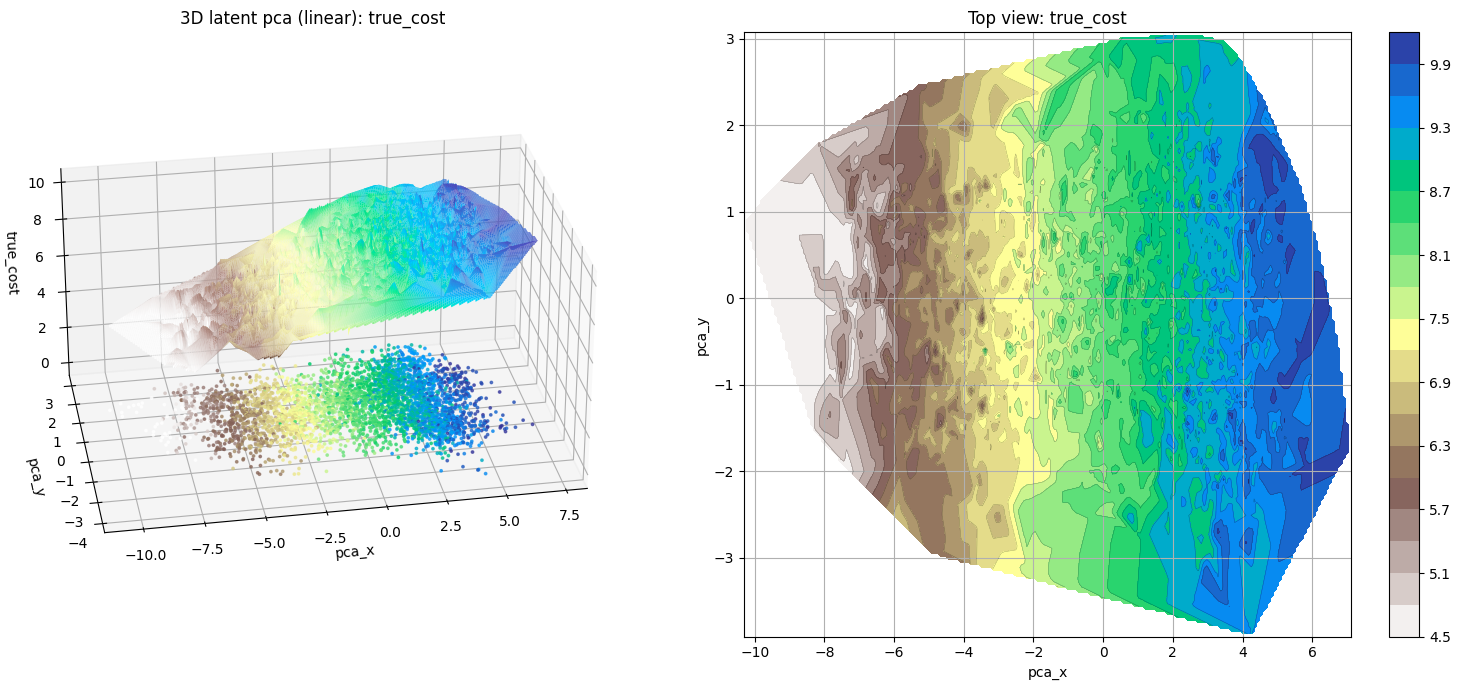

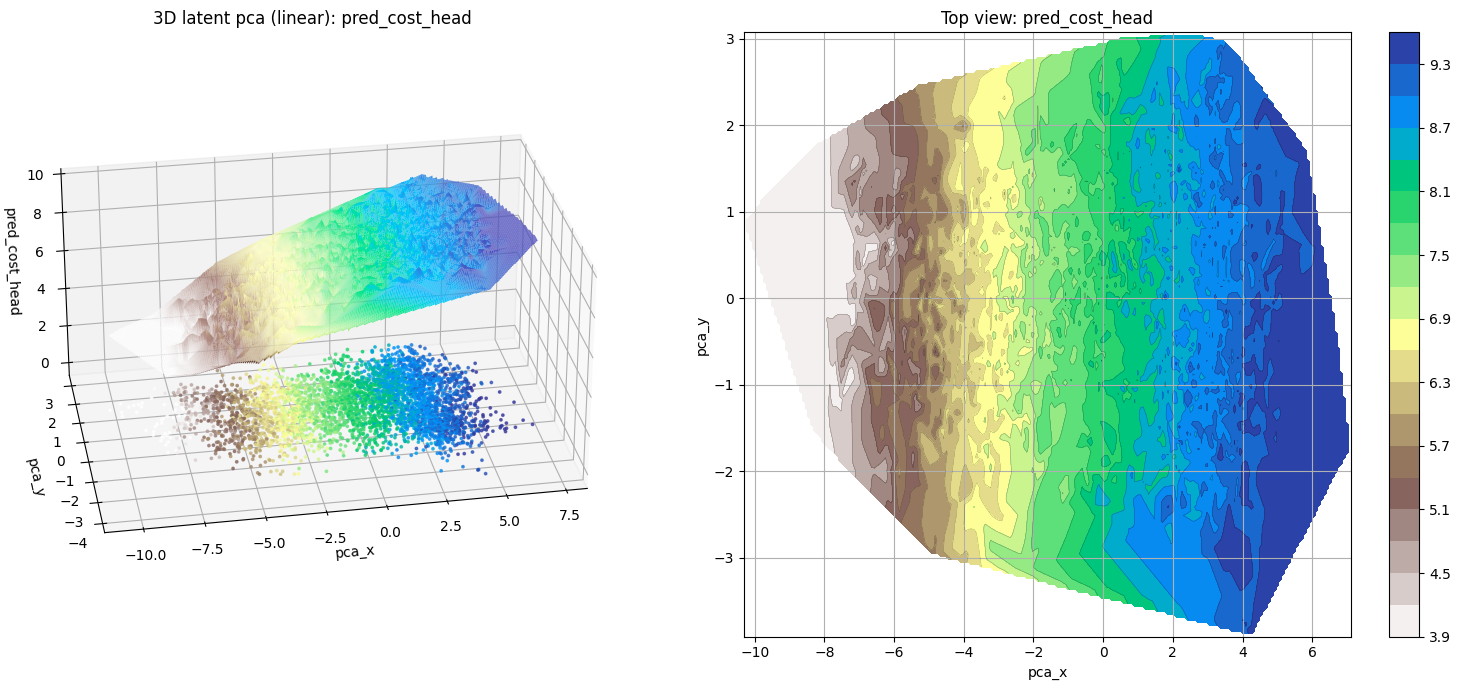

In [6]:
save=False
plot_type="pca"
interp_type="linear"
reverse_x = False

plot_latent_surface_with_topview(
    latent_df,
    z_col='true_cost',
    plot_type=plot_type,
    interp_type=interp_type,
    save=save,
    reverse_x=reverse_x,
)
plot_latent_surface_with_topview(
    latent_df,
    z_col='pred_cost_head',
    plot_type=plot_type,
    interp_type=interp_type,
    save=save,
    reverse_x=reverse_x,
)
# plot_latent_surface_with_topview(
#     latent_df,
#     z_col='pred_cost_vec',
#     plot_type=plot_type,
#     interp_type=interp_type,
#     save=save,
#     reverse_x=reverse_x,
# )

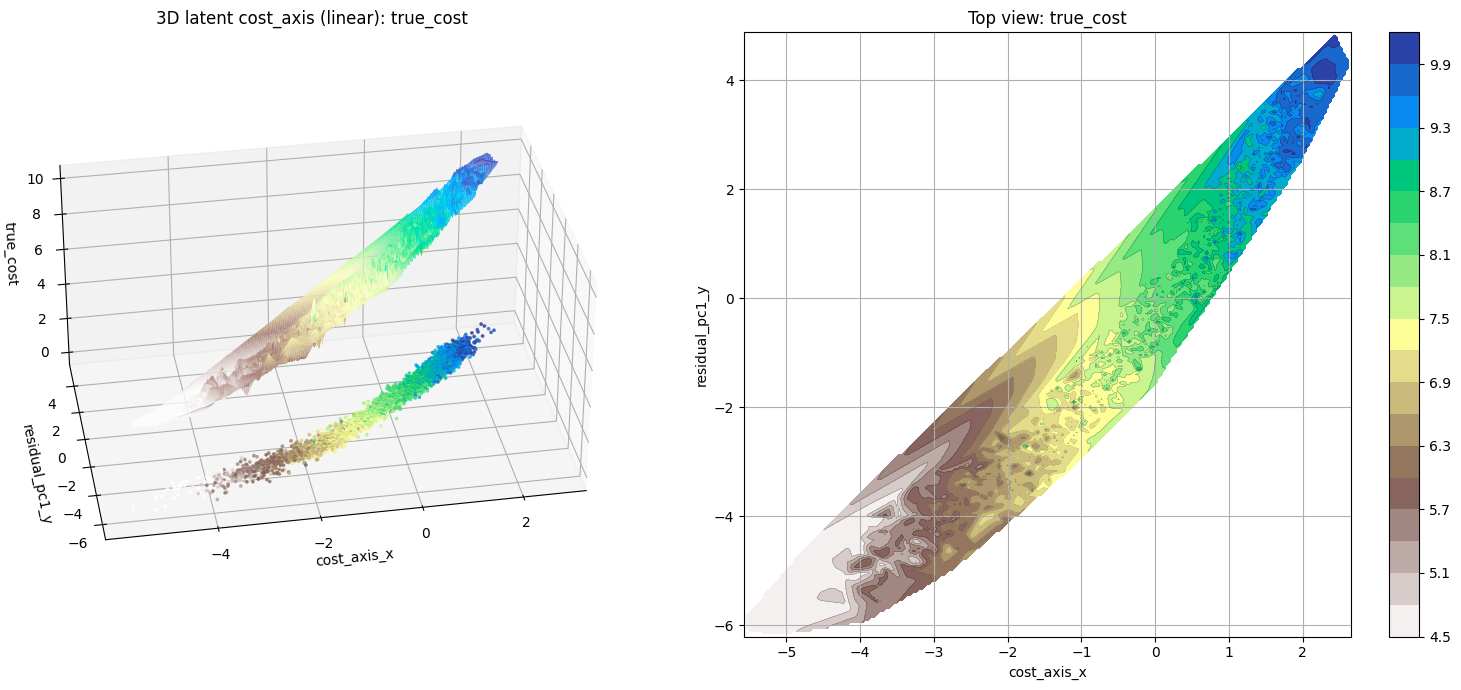

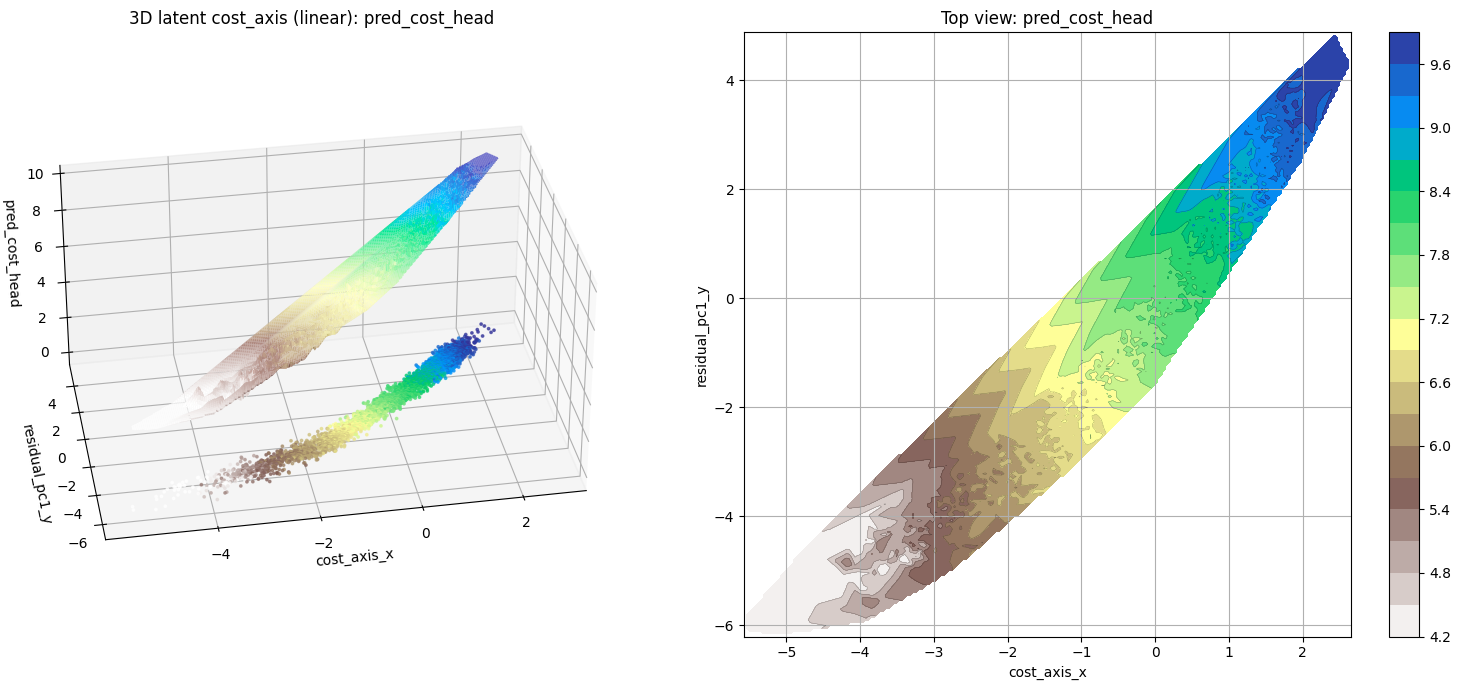

In [8]:
save = False
interp_type = 'linear'
reverse_x = False
elev = 32

plot_latent_surface_with_topview(
    latent_df,
    z_col='true_cost',
    plot_type='cost_axis',
    interp_type=interp_type,
    reverse_x=reverse_x,
    elev=elev,
    save=save,
)
plot_latent_surface_with_topview(
    latent_df,
    z_col='pred_cost_head',
    plot_type='cost_axis',
    interp_type=interp_type,
    reverse_x=reverse_x,
    elev=elev,
    save=save,
)

In [7]:
import numpy as np
import pandas as pd

try:
    from scipy.stats import spearmanr
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


def spearman_corr_from_df(
    df,
    x_col="cost_axis_x",
    y_col="true_cost",
):
    sub = df[[x_col, y_col]].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()

    n = len(sub)
    if n < 2:
        return {
            "x_col": x_col,
            "y_col": y_col,
            "n": n,
            "spearman_rho": np.nan,
            "p_value": np.nan,
        }

    x = sub[x_col].to_numpy()
    y = sub[y_col].to_numpy()

    if _HAS_SCIPY:
        rho, p = spearmanr(x, y)
    else:
        # scipy 없을 때 rank 기반 pandas 상관계수로 대체
        xr = pd.Series(x).rank(method="average")
        yr = pd.Series(y).rank(method="average")
        rho = float(xr.corr(yr, method="pearson"))
        p = np.nan

    return {
        "x_col": x_col,
        "y_col": y_col,
        "n": n,
        "spearman_rho": float(rho),
        "p_value": float(p) if pd.notna(p) else np.nan,
    }
for col in ["cost_axis_x", "pca_x", "pred_cost_head"]:
    result = spearman_corr_from_df(latent_df, x_col=col, y_col="true_cost")
    print(result)

for split_name, sub_df in latent_df.groupby("split"):
    result = spearman_corr_from_df(sub_df, x_col="cost_axis_x", y_col="true_cost")
    print(split_name, result)

{'x_col': 'cost_axis_x', 'y_col': 'true_cost', 'n': 0, 'spearman_rho': nan, 'p_value': nan}
{'x_col': 'pca_x', 'y_col': 'true_cost', 'n': 3899, 'spearman_rho': 0.9681187302172972, 'p_value': 0.0}
{'x_col': 'pred_cost_head', 'y_col': 'true_cost', 'n': 3899, 'spearman_rho': 0.9512548347941477, 'p_value': 0.0}
train {'x_col': 'cost_axis_x', 'y_col': 'true_cost', 'n': 0, 'spearman_rho': nan, 'p_value': nan}
val {'x_col': 'cost_axis_x', 'y_col': 'true_cost', 'n': 0, 'spearman_rho': nan, 'p_value': nan}


In [ ]:

# 필요하면 csv로 내보내라.
# OUTPUT_CSV = CKPT_PATH.with_suffix(f'.latent_pca_{SPLIT}.csv')
# export_df = latent_df.drop(columns=['z', 'mu', 'logvar']).copy()
# export_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
# print('saved:', OUTPUT_CSV)
# export_df.head()
